# EOT Captures — Database Exploration

Analyze the `eot_captures` table in DuckDB (~170M rows, 15 federal .gov agencies, crawl years 2004–2020).

In [ ]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from domain_analysis import (
    base_domain_sql,
    subdomain_sql,
    build_domain_summary,
    build_subdomain_breakdown,
)

con = duckdb.connect("eot.duckdb", read_only=True)

# Quick overview
con.sql("""
    SELECT
        COUNT(*)              AS total_rows,
        COUNT(DISTINCT host)  AS distinct_hosts,
        COUNT(DISTINCT crawl_year) AS crawl_years
    FROM eot_captures
""").show()


In [ ]:
# SURT-derived base_domain and subdomain expressions (replaces the old host CASE).
# SURT keys are parsed from the `surtkey` column populated during CDXJ load.
# See domain_analysis.py and http://crawler.archive.org/articles/user_manual/glossary.html#surt
TARGET_DOMAINS = [
    'usda.gov', 'commerce.gov', 'defense.gov', 'ed.gov', 'energy.gov',
    'hhs.gov', 'dhs.gov', 'hud.gov', 'doi.gov', 'justice.gov',
    'dol.gov', 'state.gov', 'transportation.gov', 'treasury.gov', 'va.gov',
]
DOMAIN_LIST_SQL = ", ".join(f"'{d}'" for d in TARGET_DOMAINS)

# Drop-in replacement for the old host-based BASE_DOMAIN_EXPR.
# Non-target base domains (if any leaked through the load filter) become 'other'.
_BD = base_domain_sql()
BASE_DOMAIN_EXPR = (
    f"CASE WHEN ({_BD}) IN ({DOMAIN_LIST_SQL}) THEN ({_BD}) ELSE 'other' END"
)
SUBDOMAIN_EXPR = subdomain_sql()

print("BASE_DOMAIN_EXPR (SURT-based):", BASE_DOMAIN_EXPR[:120], "...")


## DomainDataSummary — high-level structure

One row per target domain with SURT-derived subdomain counts.

In [ ]:
domain_summary = build_domain_summary(con)
domain_summary


## 1. Domain Rankings (largest → smallest)

In [20]:
domain_counts = con.sql(f"""
    SELECT {BASE_DOMAIN_EXPR} AS base_domain,
           COUNT(*) AS captures
    FROM eot_captures
    GROUP BY 1
    ORDER BY captures DESC
""").df()
domain_counts

,base_domain,captures
0,usda.gov,54001869
1,commerce.gov,22978500
2,ed.gov,19609568
3,treasury.gov,16835082
4,hhs.gov,11201735
5,va.gov,8794527
6,dhs.gov,7980602
7,energy.gov,7165963
8,hud.gov,6195048
9,state.gov,5360189


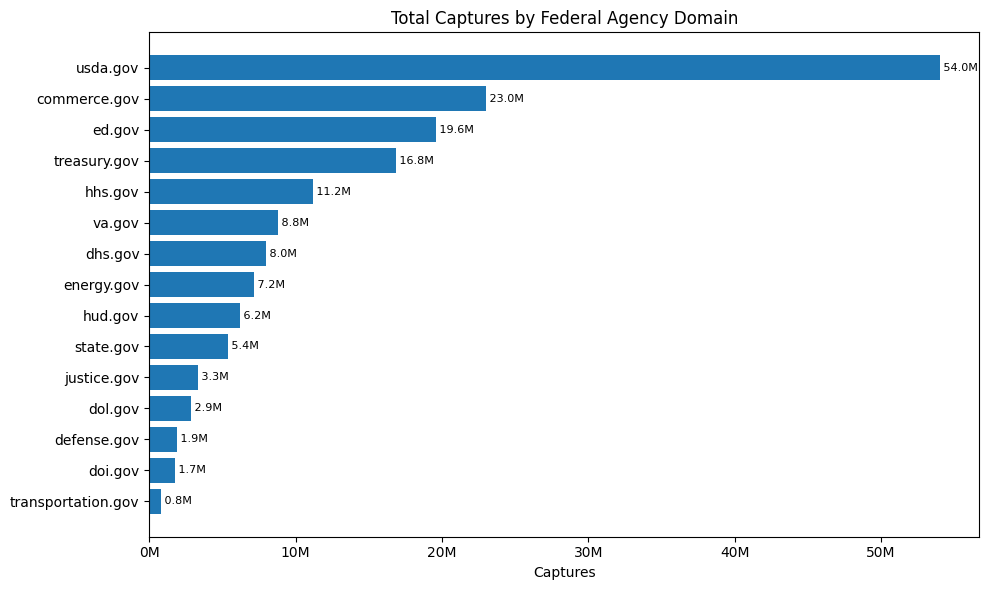

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(domain_counts['base_domain'][::-1], domain_counts['captures'][::-1])
ax.set_xlabel('Captures')
ax.set_title('Total Captures by Federal Agency Domain')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
for bar in bars:
    w = bar.get_width()
    ax.text(w, bar.get_y() + bar.get_height()/2, f' {w/1e6:.1f}M',
            va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 2. Top Subdomains per Agency

In [ ]:
# Top 10 SUBDOMAINS (SURT-derived) per agency + unique subdomain counts.
# Replaces the old host-based version; subdomains are extracted from surtkey,
# so 'data.transportation.gov' is recognized as subdomain='data' regardless of
# host formatting quirks.
top_subs = con.sql(f"""
    WITH ranked AS (
        SELECT
            {BASE_DOMAIN_EXPR} AS base_domain,
            CASE WHEN ({SUBDOMAIN_EXPR}) = '' THEN '(bare)' ELSE ({SUBDOMAIN_EXPR}) END AS subdomain,
            COUNT(*) AS captures,
            ROW_NUMBER() OVER (
                PARTITION BY ({BASE_DOMAIN_EXPR})
                ORDER BY COUNT(*) DESC
            ) AS rn
        FROM eot_captures
        WHERE surtkey IS NOT NULL
        GROUP BY 1, 2
    )
    SELECT base_domain, subdomain, captures
    FROM ranked
    WHERE rn <= 10 AND base_domain != 'other'
    ORDER BY base_domain, captures DESC
""").df()
top_subs


In [ ]:
# Unique subdomain counts per agency (horizontal bar)
subdom_counts_df = domain_summary.sort_values('unique_subdomains', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(subdom_counts_df['base_domain'], subdom_counts_df['unique_subdomains'],
        color='#3498db')
for i, (v, n) in enumerate(zip(subdom_counts_df['base_domain'],
                                subdom_counts_df['unique_subdomains'])):
    ax.text(n + max(subdom_counts_df['unique_subdomains']) * 0.005, i,
            f'{n:,}', va='center', fontsize=10)
ax.set_xlabel('Unique subdomains (SURT-derived)')
ax.set_title('Unique subdomains per target domain')
plt.tight_layout()
plt.show()


## 3. Captures by Crawl Year

In [23]:
year_counts = con.sql("""
    SELECT crawl_year, COUNT(*) AS captures
    FROM eot_captures
    GROUP BY 1
    ORDER BY 1
""").df()
year_counts

,crawl_year,captures
0,2004,6702277
1,2008,11752896
2,2012,5425313
3,2016,19443387
4,2020,127396852


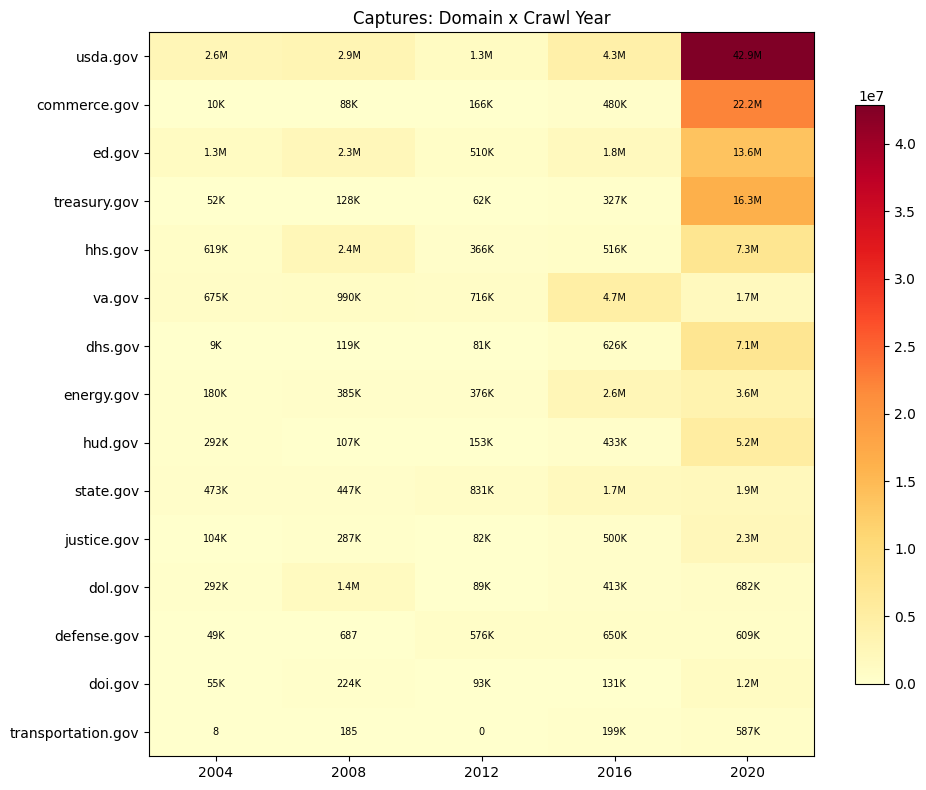

In [24]:
# Domain x Year heatmap
pivot = con.sql(f"""
    SELECT {BASE_DOMAIN_EXPR} AS base_domain,
           crawl_year,
           COUNT(*) AS captures
    FROM eot_captures
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

heatmap_data = pivot.pivot(index='base_domain', columns='crawl_year', values='captures').fillna(0)
# Sort rows by total captures descending
heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title('Captures: Domain x Crawl Year')

# Annotate cells
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        text = f'{val/1e6:.1f}M' if val >= 1e6 else f'{val/1e3:.0f}K' if val >= 1e3 else str(int(val))
        ax.text(j, i, text, ha='center', va='center', fontsize=7)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 4. HTTP Status Code Distribution

In [25]:
status_dist = con.sql("""
    SELECT
        status,
        COUNT(*) AS captures,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM eot_captures
    GROUP BY 1
    ORDER BY captures DESC
""").df()
status_dist.head(20)

,status,captures,pct
0,200,148889453,87.21
1,302,8942297,5.24
2,301,5049875,2.96
3,403,4305499,2.52
4,404,2845564,1.67
5,503,252939,0.15
6,500,233066,0.14
7,400,82095,0.05
8,303,42927,0.03
9,401,29481,0.02


In [26]:
# Status class breakdown per domain
status_by_domain = con.sql(f"""
    SELECT
        {BASE_DOMAIN_EXPR} AS base_domain,
        CASE
            WHEN status BETWEEN 200 AND 299 THEN '2xx'
            WHEN status BETWEEN 300 AND 399 THEN '3xx'
            WHEN status BETWEEN 400 AND 499 THEN '4xx'
            WHEN status BETWEEN 500 AND 599 THEN '5xx'
            ELSE 'other'
        END AS status_class,
        COUNT(*) AS captures
    FROM eot_captures
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

status_pivot = status_by_domain.pivot(index='base_domain', columns='status_class', values='captures').fillna(0)
status_pivot['total'] = status_pivot.sum(axis=1)
# Show as percentages
status_pct = status_pivot.drop(columns='total').div(status_pivot['total'], axis=0) * 100
status_pct = status_pct.round(1)
status_pct.sort_values('2xx', ascending=False)

status_class,2xx,3xx,4xx,5xx,other
base_domain,,,,,
commerce.gov,99.3,0.2,0.5,0.1,0.0
dhs.gov,97.4,1.6,0.8,0.2,0.0
treasury.gov,93.6,5.9,0.5,0.0,0.0
usda.gov,92.8,5.0,1.6,0.6,0.0
doi.gov,91.3,4.4,4.2,0.1,0.0
ed.gov,90.9,7.6,1.3,0.2,0.0
justice.gov,89.1,9.2,1.7,0.0,0.0
transportation.gov,88.2,5.2,5.1,1.5,0.0
energy.gov,85.5,9.9,4.4,0.3,0.0


## 5. MIME Type Distribution

In [27]:
mime_dist = con.sql("""
    SELECT
        COALESCE(mime, '(null)') AS mime,
        COUNT(*) AS captures,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM eot_captures
    GROUP BY 1
    ORDER BY captures DESC
    LIMIT 20
""").df()
mime_dist

,mime,captures,pct
0,text/html,147595515,86.45
1,application/pdf,6488657,3.80
2,(null),5268781,3.09
3,image/jpeg,3073158,1.80
4,image/gif,1609730,0.94
5,text/plain,1294474,0.76
6,image/png,913829,0.54
7,application/msword,405597,0.24
8,application/vnd.ms-excel,385622,0.23
9,text/css,330892,0.19


In [28]:
# mime vs mime_detected mismatch rate
con.sql("""
    SELECT
        COUNT(*) AS total,
        SUM(CASE WHEN mime != mime_detected THEN 1 ELSE 0 END) AS mismatched,
        ROUND(100.0 * SUM(CASE WHEN mime != mime_detected THEN 1 ELSE 0 END) / COUNT(*), 2) AS mismatch_pct
    FROM eot_captures
    WHERE mime IS NOT NULL AND mime_detected IS NOT NULL
""").show()

┌───────────┬────────────┬──────────────┐
│   total   │ mismatched │ mismatch_pct │
│   int64   │   int128   │    double    │
├───────────┼────────────┼──────────────┤
│ 141174849 │    9031309 │          6.4 │
└───────────┴────────────┴──────────────┘



## 6. Content Size Stats

In [29]:
size_stats = con.sql(f"""
    SELECT
        {BASE_DOMAIN_EXPR} AS base_domain,
        COUNT(*) AS n,
        MIN("length") AS min_bytes,
        CAST(MEDIAN("length") AS BIGINT) AS median_bytes,
        CAST(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY "length") AS BIGINT) AS p95_bytes,
        MAX("length") AS max_bytes,
        CAST(AVG("length") AS BIGINT) AS avg_bytes,
        CAST(SUM("length") AS BIGINT) AS total_bytes
    FROM eot_captures
    WHERE "length" IS NOT NULL AND "length" > 0
    GROUP BY 1
    ORDER BY total_bytes DESC
""").df()
size_stats['total_gb'] = (size_stats['total_bytes'] / 1e9).round(2)
size_stats

,base_domain,n,min_bytes,median_bytes,p95_bytes,max_bytes,avg_bytes,total_bytes,total_gb
0,usda.gov,54001869,137,10763,50898,4974222264,80902,4368859218155,4368.86
1,ed.gov,19609567,142,5622,62000,1529767643,77338,1516569973630,1516.57
2,energy.gov,7165963,145,11640,232999,1659566347,173920,1246301139503,1246.30
3,va.gov,8794527,130,4515,196247,1361699264,123289,1084264834500,1084.26
4,dhs.gov,7980602,145,25673,106592,1445665790,90303,720674409954,720.67
5,commerce.gov,22978500,184,15053,37837,425588163,26511,609191475821,609.19
6,hhs.gov,11201735,132,2567,16189,517083645,36781,412009344742,412.01
7,state.gov,5360189,179,6556,116422,822935162,64554,346019474138,346.02
8,treasury.gov,16835082,215,3322,3346,1033943114,19301,324925563891,324.93
9,justice.gov,3314182,214,14998,133537,926692457,89021,295030848401,295.03


## 7. Duplicate Content (Digest Analysis)

In [30]:
dedup = con.sql(f"""
    SELECT
        {BASE_DOMAIN_EXPR} AS base_domain,
        COUNT(*) AS total_captures,
        COUNT(DISTINCT digest) AS unique_digests,
        ROUND(100.0 * (1 - COUNT(DISTINCT digest)::FLOAT / COUNT(*)), 1) AS duplication_pct
    FROM eot_captures
    WHERE digest IS NOT NULL
    GROUP BY 1
    ORDER BY duplication_pct DESC
""").df()
dedup

RuntimeError: Query interrupted

In [ ]:
# Overall dedup stats
con.sql("""
    SELECT
        COUNT(*) AS total_captures,
        COUNT(DISTINCT digest) AS unique_digests,
        ROUND(100.0 * (1 - COUNT(DISTINCT digest)::FLOAT / COUNT(*)), 1) AS duplication_pct
    FROM eot_captures
    WHERE digest IS NOT NULL
""").show()

## 8. Temporal Patterns (Fetch Activity Over Time)

In [ ]:
temporal = con.sql("""
    SELECT
        crawl_year,
        substr(fetch_timestamp, 1, 6) AS yyyymm,
        COUNT(*) AS captures
    FROM eot_captures
    WHERE fetch_timestamp IS NOT NULL AND length(fetch_timestamp) >= 6
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

fig, axes = plt.subplots(len(temporal['crawl_year'].unique()), 1,
                         figsize=(12, 3 * len(temporal['crawl_year'].unique())),
                         sharex=False)
if not hasattr(axes, '__iter__'):
    axes = [axes]

for ax, (year, grp) in zip(axes, temporal.groupby('crawl_year')):
    ax.bar(range(len(grp)), grp['captures'].values)
    ax.set_xticks(range(len(grp)))
    ax.set_xticklabels(grp['yyyymm'].values, rotation=45, fontsize=7)
    ax.set_title(f'EOT-{year}')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

In [ ]:
con.close()

## 9. Parquet vs CDXJ Comparison

Compare the pre-built parquet index (`data/parquet/`) against the CDXJ-loaded DuckDB (`eot_captures`).
The parquet files contain ALL crawled domains; the CDXJ DB is filtered to 15 TARGET_DOMAINS.

In [ ]:
# Total row counts: parquet (all domains) vs CDXJ DB (filtered to TARGET_DOMAINS)
parquet_total = con.sql("""
    SELECT COUNT(*) AS parquet_rows
    FROM read_parquet('data/parquet/EOT-*/*.parquet')
""").df()

cdxj_total = con.sql("SELECT COUNT(*) AS cdxj_rows FROM eot_captures").df()

print(f"Parquet (all domains):       {parquet_total['parquet_rows'][0]:>15,}")
print(f"CDXJ DB (15 target domains): {cdxj_total['cdxj_rows'][0]:>15,}")

In [ ]:
# Per-year comparison
comparison = con.sql(f"""
    WITH pq AS (
        SELECT
            regexp_extract(filename, 'EOT-(\\d{{4}})', 1) AS crawl_year,
            COUNT(*) AS parquet_rows
        FROM read_parquet('data/parquet/EOT-*/*.parquet', filename=true)
        GROUP BY 1
    ),
    cdxj AS (
        SELECT crawl_year, COUNT(*) AS cdxj_rows
        FROM eot_captures
        GROUP BY 1
    )
    SELECT
        COALESCE(pq.crawl_year, cdxj.crawl_year) AS crawl_year,
        pq.parquet_rows,
        cdxj.cdxj_rows,
        pq.parquet_rows - cdxj.cdxj_rows AS diff
    FROM pq
    FULL OUTER JOIN cdxj ON pq.crawl_year = cdxj.crawl_year
    ORDER BY 1
""").df()
comparison

In [ ]:
# Filter parquet to the same 15 TARGET_DOMAINS and compare apples-to-apples
# Uses url_host_registered_domain from parquet schema
TARGET_DOMAINS = [
    'usda.gov', 'commerce.gov', 'defense.gov', 'ed.gov', 'energy.gov',
    'hhs.gov', 'dhs.gov', 'hud.gov', 'doi.gov', 'justice.gov',
    'dol.gov', 'state.gov', 'transportation.gov', 'treasury.gov', 'va.gov',
]
domain_list = ", ".join(f"'{d}'" for d in TARGET_DOMAINS)

pq_filtered = con.sql(f"""
    WITH pq AS (
        SELECT
            regexp_extract(filename, 'EOT-(\\d{{4}})', 1) AS crawl_year,
            url_host_registered_domain AS domain,
            COUNT(*) AS parquet_rows
        FROM read_parquet('data/parquet/EOT-*/*.parquet', filename=true)
        WHERE url_host_registered_domain IN ({domain_list})
        GROUP BY 1, 2
    ),
    cdxj AS (
        SELECT
            crawl_year,
            {BASE_DOMAIN_EXPR} AS domain,
            COUNT(*) AS cdxj_rows
        FROM eot_captures
        GROUP BY 1, 2
    )
    SELECT
        COALESCE(pq.crawl_year, cdxj.crawl_year) AS crawl_year,
        COALESCE(pq.domain, cdxj.domain) AS domain,
        pq.parquet_rows,
        cdxj.cdxj_rows,
        COALESCE(pq.parquet_rows, 0) - COALESCE(cdxj.cdxj_rows, 0) AS diff
    FROM pq
    FULL OUTER JOIN cdxj ON pq.crawl_year = cdxj.crawl_year AND pq.domain = cdxj.domain
    ORDER BY 1, 2
""").df()
pq_filtered

In [ ]:
# Summary: total diff across all domains when filtered to same 15
summary = pq_filtered.groupby('crawl_year')[['parquet_rows', 'cdxj_rows', 'diff']].sum()
summary['pct_diff'] = (100.0 * summary['diff'] / summary['cdxj_rows']).round(2)
summary